# 🤖 Modelos Clásicos de Machine Learning

## Entrenamiento y Evaluación de Modelos para Análisis de Sentimientos

En este notebook entrenaremos **3 modelos clásicos** para clasificar sentimientos usando las features TF-IDF del notebook anterior.

### Objetivos del Notebook:
1. **Preparar el dataset** - Split train/test
2. **Entrenar 3 modelos clásicos**:
   - Naive Bayes (Multinomial)
   - Support Vector Machine (SVM Lineal)
   - Logistic Regression
3. **Evaluar modelos** - Métricas de rendimiento
4. **Comparar resultados** - Tablas y gráficos
5. **Analizar feature importance** - Qué palabras son decisivas
6. **Visualizar matrices de confusión**
7. **Pruebas interactivas** - Predecir sentimientos nuevos

### ¿Por qué estos 3 modelos?

| Modelo | Ventajas | Desventajas | Cuándo usar |
|--------|----------|-------------|-------------|
| **Naive Bayes** | Muy rápido, funciona bien con datos escasos | Asume independencia entre features | Baseline, datasets pequeños |
| **SVM** | Excelente con features TF-IDF, robusto | Lento con datos muy grandes | Texto, datos altos-dimensionales |
| **Logistic Regression** | Rápido, interpretable, probabilidades | Requiere scaling a veces | Baseline, producción |

Todos ellos funcionan bien con **TF-IDF** (features sparse y altos-dimensionales).

## Parte 1: Configuración e Imports

In [3]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, auc
)

# Configurar visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
%matplotlib inline

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [4]:
# Configurar rutas
NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
REPORTS_DIR = PROJECT_DIR / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Rutas configuradas")
print(f"   - Proyecto: {PROJECT_DIR}")
print(f"   - Reportes: {REPORTS_DIR}")

📁 Rutas configuradas
   - Proyecto: /
   - Reportes: /reports


## Parte 2: Preparar Dataset

In [5]:
# CARGAR Y PREPARAR DATASET IMDB REAL
print("=" * 70)
print("📥 CARGANDO Y PREPARANDO DATASET IMDB")
print("=" * 70)

from tensorflow.keras.datasets import imdb
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
import re

# Descargar recursos NLTK
print("\n⏳ Descargando recursos...")
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Cargar dataset IMDB
print("⏳ Cargando dataset IMDB...")
(X_train_full, y_train_full), (X_test_full, y_test_full) = imdb.load_data(num_words=10000)

# Obtener diccionario de palabras
word_index = imdb.get_word_index()
reverse_word_index = {v: k for k, v in word_index.items()}

# Función para decodificar reviews
def decode_review(encoded_review, reverse_word_index):
    """Convierte review tokenizada (números) a texto."""
    decoded_text = ""
    for word_idx in encoded_review:
        if word_idx >= 3:
            decoded_text += " " + reverse_word_index.get(word_idx, "<unknown>")
    return decoded_text.strip()

# Función para preprocesar texto
def preprocess_review(text):
    """Limpia y prepara el texto."""
    # Convertir a minúsculas
    text = text.lower()
    # Remover caracteres especiales
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenizar
    tokens = word_tokenize(text)
    # Remover stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

# Usar una muestra del dataset para eficiencia
n_samples = 1000  # Usar 1000 reviews para entrenamiento
print(f"\n⏳ Preprocesando {n_samples} reviews...")

reviews = []
labels = []

for i in range(n_samples):
    decoded = decode_review(X_train_full[i], reverse_word_index)
    processed = preprocess_review(decoded)
    reviews.append(processed)
    labels.append(y_train_full[i])

print(f"✅ Dataset preparado:")
print(f"   - Total reviews: {len(reviews)}")
print(f"   - Positivas: {sum(labels)}")
print(f"   - Negativas: {len(labels) - sum(labels)}")
print(f"   - Balanceo: {sum(labels)/len(labels)*100:.1f}% positivas")

📥 CARGANDO Y PREPARANDO DATASET IMDB

⏳ Descargando recursos...
⏳ Cargando dataset IMDB...

⏳ Preprocesando 1000 reviews...
✅ Dataset preparado:
   - Total reviews: 1000
   - Positivas: 494
   - Negativas: 506
   - Balanceo: 49.4% positivas


In [ ]:
print("\n" + "=" * 70)
print("🔀 SPLIT TRAIN/TEST")
print("=" * 70)

# ⚠️ IMPORTANTE: División de datos para evitar overfitting
# El modelo SOLO se entrena en X_train / y_train
# El test set se usa SOLO para evaluación final (nunca en entrenamiento)
# Mantener balanceo de clases en ambos conjuntos es crítico
X_train, X_test, y_train, y_test = train_test_split(
    reviews, labels,
    test_size=0.2,           # 20% para test
    random_state=42,         # Reproducibilidad
    stratify=labels          # Mantener balanceo
)

print(f"\n📊 Distribución del split:")
print(f"   - Training: {len(X_train)} reviews ({len(X_train)/len(reviews)*100:.1f}%)")
print(f"   - Test: {len(X_test)} reviews ({len(X_test)/len(reviews)*100:.1f}%)")

print(f"\n💡 ESTRATEGIA:")
print(f"   1. X_train / y_train: Usados para FIT del vectorizador y modelos")
print(f"   2. X_test / y_test: Usados SOLO para evaluación final")
print(f"   3. NUNCA se filtra ni modifica el test set")

print(f"\n📈 Sentimientos en training:")
print(f"   - Positivos: {sum(y_train)} / {len(y_train)} ({sum(y_train)/len(y_train)*100:.1f}%)")
print(f"   - Negativos: {len(y_train) - sum(y_train)} / {len(y_train)} ({(1 - sum(y_train)/len(y_train))*100:.1f}%)")

print(f"\n📈 Sentimientos en test:")
print(f"   - Positivos: {sum(y_test)} / {len(y_test)} ({sum(y_test)/len(y_test)*100:.1f}%)")
print(f"   - Negativos: {len(y_test) - sum(y_test)} / {len(y_test)} ({(1 - sum(y_test)/len(y_test))*100:.1f}%)")

In [7]:
print("\n" + "=" * 70)
print("📊 CREAR FEATURES TF-IDF")
print("=" * 70)

# Vectorizador TF-IDF con parámetros razonables para 1000 reviews
vectorizer = TfidfVectorizer(
    max_features=100,        # Limitar a 100 palabras más frecuentes
    min_df=2,                # Palabra debe aparecer en al menos 2 documentos
    max_df=0.8,              # Palabra no debe aparecer en más del 80% de documentos
    ngram_range=(1, 2),      # Usar unigramas y bigramas
    stop_words='english'
)

# Fit en training, transform en train y test
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"\n📚 Características de TF-IDF:")
print(f"   - Features creadas: {X_train_tfidf.shape[1]}")
print(f"   - Sparsity (% de ceros): {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])) * 100:.1f}%")

print(f"\n📐 Matriz de features:")
print(f"   - Training: {X_train_tfidf.shape[0]} documentos × {X_train_tfidf.shape[1]} features")
print(f"   - Test: {X_test_tfidf.shape[0]} documentos × {X_test_tfidf.shape[1]} features")

print(f"\n🔝 Primeras 20 palabras del vocabulario:")
feature_names = vectorizer.get_feature_names_out()
print(f"   {list(feature_names[:20])}")


📊 CREAR FEATURES TF-IDF

📚 Características de TF-IDF:
   - Features creadas: 100
   - Sparsity (% de ceros): 83.4%

📐 Matriz de features:
   - Training: 800 documentos × 100 features
   - Test: 200 documentos × 100 features

🔝 Primeras 20 palabras del vocabulario:
   ['acting', 'action', 'actors', 'actually', 'away', 'bad', 'best', 'better', 'big', 'bit', 'book', 'cast', 'character', 'characters', 'come', 'comedy', 'day', 'didnt', 'director', 'doesnt']


## Parte 3: Entrenar Modelos

In [8]:
print("=" * 70)
print("🤖 ENTRENAMIENTO DE MODELOS")
print("=" * 70)

# 1. Naive Bayes
print("\n1️⃣  Naive Bayes Multinomial...")
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, y_train)
print("   ✅ Entrenado")

# 2. SVM Lineal
print("\n2️⃣  Support Vector Machine (SVM) Lineal...")
model_svm = LinearSVC(max_iter=10000, random_state=42)
model_svm.fit(X_train_tfidf, y_train)
print("   ✅ Entrenado")

# 3. Logistic Regression
print("\n3️⃣  Logistic Regression...")
model_lr = LogisticRegression(max_iter=10000, random_state=42)
model_lr.fit(X_train_tfidf, y_train)
print("   ✅ Entrenado")

print("\n" + "=" * 70)
print("✅ TODOS LOS MODELOS ENTRENADOS")
print("=" * 70)

🤖 ENTRENAMIENTO DE MODELOS

1️⃣  Naive Bayes Multinomial...
   ✅ Entrenado

2️⃣  Support Vector Machine (SVM) Lineal...
   ✅ Entrenado

3️⃣  Logistic Regression...
   ✅ Entrenado

✅ TODOS LOS MODELOS ENTRENADOS


## Parte 4: Prediciones

In [9]:
# Hacer predicciones
y_pred_nb = model_nb.predict(X_test_tfidf)
y_pred_svm = model_svm.predict(X_test_tfidf)
y_pred_lr = model_lr.predict(X_test_tfidf)

print("✅ Predicciones completadas para los 3 modelos")

✅ Predicciones completadas para los 3 modelos


## Parte 5: Evaluación de Modelos

### Métricas Explicadas:

- **Accuracy**: Porcentaje total de predicciones correctas
  - Fórmula: (TP + TN) / Total
  - Rango: 0-1 (o 0%-100%)

- **Precision**: De las predicciones positivas, cuántas fueron correctas
  - Fórmula: TP / (TP + FP)
  - Responde: "Si predice POSITIVO, ¿qué tan correcto está?"

- **Recall (Sensibilidad)**: De los casos positivos reales, cuántos encontró
  - Fórmula: TP / (TP + FN)
  - Responde: "¿Encontró todos los casos positivos?"

- **F1-Score**: Media armónica entre Precision y Recall
  - Fórmula: 2 × (Precision × Recall) / (Precision + Recall)
  - Balance entre Precision y Recall

In [10]:
print("=" * 70)
print("📊 EVALUACIÓN - NAIVE BAYES")
print("=" * 70)

acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print(f"\n📈 Métricas:")
print(f"   - Accuracy:  {acc_nb:.4f} ({acc_nb*100:.2f}%)")
print(f"   - Precision: {prec_nb:.4f} ({prec_nb*100:.2f}%)")
print(f"   - Recall:    {rec_nb:.4f} ({rec_nb*100:.2f}%)")
print(f"   - F1-Score:  {f1_nb:.4f}")

📊 EVALUACIÓN - NAIVE BAYES

📈 Métricas:
   - Accuracy:  0.6550 (65.50%)
   - Precision: 0.6667 (66.67%)
   - Recall:    0.6061 (60.61%)
   - F1-Score:  0.6349


In [11]:
print("\n" + "=" * 70)
print("📊 EVALUACIÓN - SUPPORT VECTOR MACHINE (SVM)")
print("=" * 70)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print(f"\n📈 Métricas:")
print(f"   - Accuracy:  {acc_svm:.4f} ({acc_svm*100:.2f}%)")
print(f"   - Precision: {prec_svm:.4f} ({prec_svm*100:.2f}%)")
print(f"   - Recall:    {rec_svm:.4f} ({rec_svm*100:.2f}%)")
print(f"   - F1-Score:  {f1_svm:.4f}")


📊 EVALUACIÓN - SUPPORT VECTOR MACHINE (SVM)

📈 Métricas:
   - Accuracy:  0.6350 (63.50%)
   - Precision: 0.6354 (63.54%)
   - Recall:    0.6162 (61.62%)
   - F1-Score:  0.6256


In [12]:
print("\n" + "=" * 70)
print("📊 EVALUACIÓN - LOGISTIC REGRESSION")
print("=" * 70)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"\n📈 Métricas:")
print(f"   - Accuracy:  {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"   - Precision: {prec_lr:.4f} ({prec_lr*100:.2f}%)")
print(f"   - Recall:    {rec_lr:.4f} ({rec_lr*100:.2f}%)")
print(f"   - F1-Score:  {f1_lr:.4f}")


📊 EVALUACIÓN - LOGISTIC REGRESSION

📈 Métricas:
   - Accuracy:  0.6200 (62.00%)
   - Precision: 0.6211 (62.11%)
   - Recall:    0.5960 (59.60%)
   - F1-Score:  0.6082


## Parte 6: Comparación de Modelos

In [13]:
print("=" * 70)
print("🏆 COMPARACIÓN DE MODELOS")
print("=" * 70)

# Crear tabla comparativa
comparison_df = pd.DataFrame({
    'Modelo': ['Naive Bayes', 'SVM', 'Logistic Regression'],
    'Accuracy': [acc_nb, acc_svm, acc_lr],
    'Precision': [prec_nb, prec_svm, prec_lr],
    'Recall': [rec_nb, rec_svm, rec_lr],
    'F1-Score': [f1_nb, f1_svm, f1_lr]
})

print("\n📊 Tabla de Resultados:")
print(comparison_df.to_string(index=False))

print(f"\n🏆 MEJOR MODELO (por Accuracy): {comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Modelo']}")
print(f"   Accuracy: {comparison_df['Accuracy'].max():.4f}")

🏆 COMPARACIÓN DE MODELOS

📊 Tabla de Resultados:
             Modelo  Accuracy  Precision   Recall  F1-Score
        Naive Bayes     0.655   0.666667 0.606061  0.634921
                SVM     0.635   0.635417 0.616162  0.625641
Logistic Regression     0.620   0.621053 0.595960  0.608247

🏆 MEJOR MODELO (por Accuracy): Naive Bayes
   Accuracy: 0.6550


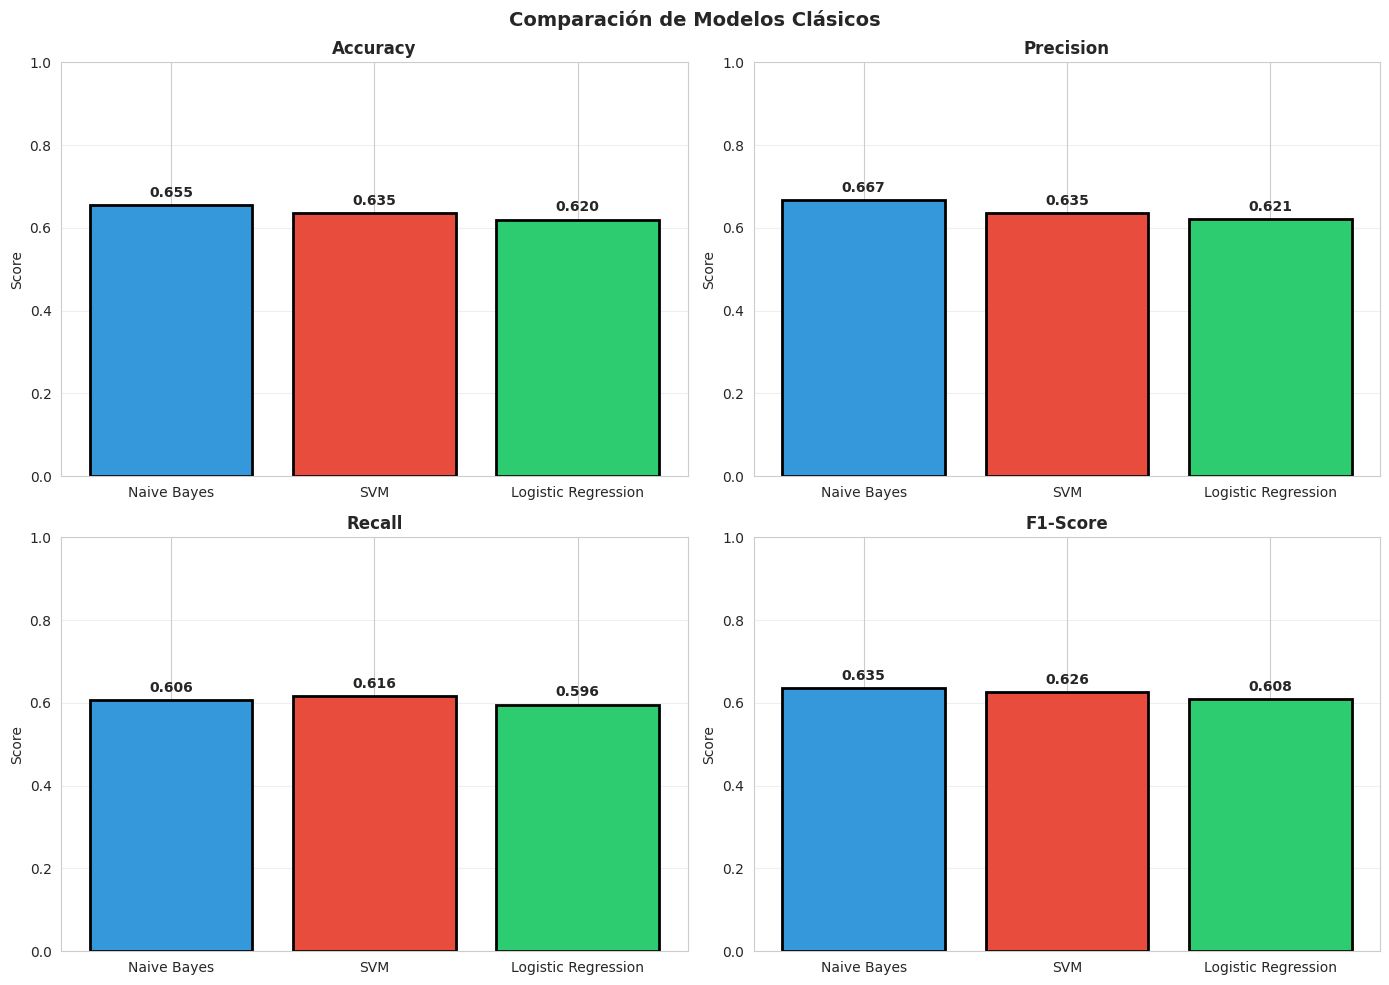

✅ Visualización guardada


In [14]:
# Visualizar comparación
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación de Modelos Clásicos', fontsize=14, fontweight='bold')

models = comparison_df['Modelo'].values
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71']

# Subplot 1: Accuracy
ax = axes[0, 0]
ax.bar(models, comparison_df['Accuracy'], color=colors, edgecolor='black', linewidth=2)
ax.set_ylabel('Score')
ax.set_title('Accuracy', fontweight='bold')
ax.set_ylim(0, 1)
for i, v in enumerate(comparison_df['Accuracy']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Subplot 2: Precision
ax = axes[0, 1]
ax.bar(models, comparison_df['Precision'], color=colors, edgecolor='black', linewidth=2)
ax.set_ylabel('Score')
ax.set_title('Precision', fontweight='bold')
ax.set_ylim(0, 1)
for i, v in enumerate(comparison_df['Precision']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Subplot 3: Recall
ax = axes[1, 0]
ax.bar(models, comparison_df['Recall'], color=colors, edgecolor='black', linewidth=2)
ax.set_ylabel('Score')
ax.set_title('Recall', fontweight='bold')
ax.set_ylim(0, 1)
for i, v in enumerate(comparison_df['Recall']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Subplot 4: F1-Score
ax = axes[1, 1]
ax.bar(models, comparison_df['F1-Score'], color=colors, edgecolor='black', linewidth=2)
ax.set_ylabel('Score')
ax.set_title('F1-Score', fontweight='bold')
ax.set_ylim(0, 1)
for i, v in enumerate(comparison_df['F1-Score']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualización guardada")

## Parte 7: Matrices de Confusión

📊 MATRICES DE CONFUSIÓN


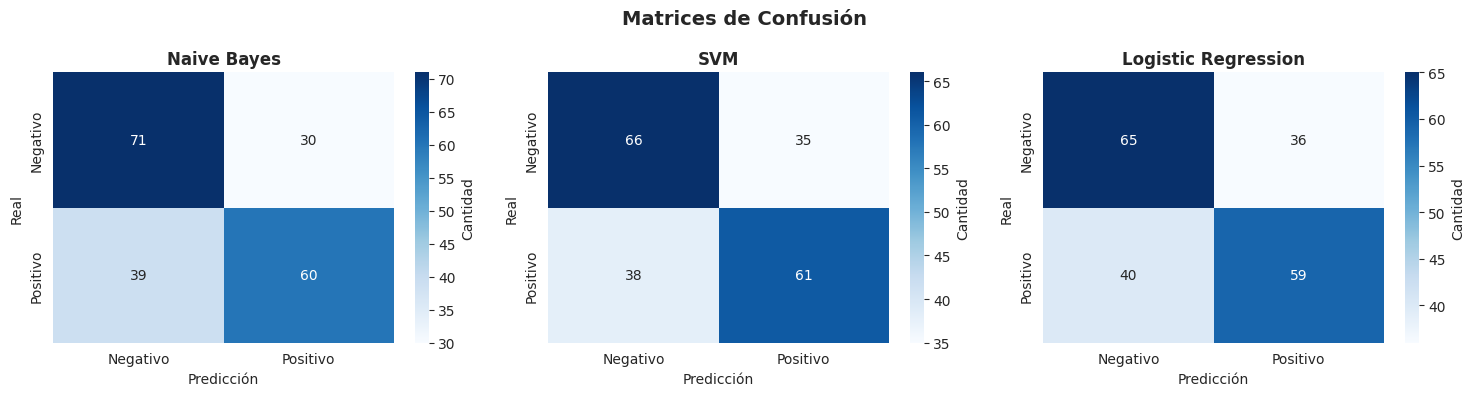

✅ Visualización guardada


In [15]:
print("=" * 70)
print("📊 MATRICES DE CONFUSIÓN")
print("=" * 70)

# Calcular matrices
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_svm = confusion_matrix(y_test, y_pred_svm)
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión', fontsize=14, fontweight='bold')

confusion_matrices = [cm_nb, cm_svm, cm_lr]
model_names = ['Naive Bayes', 'SVM', 'Logistic Regression']

for idx, (cm, name) in enumerate(zip(confusion_matrices, model_names)):
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                cbar_kws={'label': 'Cantidad'},
                xticklabels=['Negativo', 'Positivo'],
                yticklabels=['Negativo', 'Positivo'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualización guardada")

In [16]:
# Interpretar matrices
print("\n" + "=" * 70)
print("💡 INTERPRETACIÓN DE MATRIZ DE CONFUSIÓN")
print("=" * 70)

print(f"\nMatriz de Confusión:")
print(f"                Predicción")
print(f"                Neg   Pos")
print(f"Real Neg      [ TN   FP ]")
print(f"     Pos      [ FN   TP ]")

print(f"\nDonde:")
print(f"  - TN (True Negative):  Predijo negativo y era negativo ✓")
print(f"  - FP (False Positive): Predijo positivo pero era negativo ✗")
print(f"  - FN (False Negative): Predijo negativo pero era positivo ✗")
print(f"  - TP (True Positive):  Predijo positivo y era positivo ✓")

print(f"\nPara el modelo SVM:")
print(f"  - TN: {cm_svm[0,0]} (negativos correctos)")
print(f"  - FP: {cm_svm[0,1]} (falsos positivos)")
print(f"  - FN: {cm_svm[1,0]} (falsos negativos)")
print(f"  - TP: {cm_svm[1,1]} (positivos correctos)")


💡 INTERPRETACIÓN DE MATRIZ DE CONFUSIÓN

Matriz de Confusión:
                Predicción
                Neg   Pos
Real Neg      [ TN   FP ]
     Pos      [ FN   TP ]

Donde:
  - TN (True Negative):  Predijo negativo y era negativo ✓
  - FP (False Positive): Predijo positivo pero era negativo ✗
  - FN (False Negative): Predijo negativo pero era positivo ✗
  - TP (True Positive):  Predijo positivo y era positivo ✓

Para el modelo SVM:
  - TN: 66 (negativos correctos)
  - FP: 35 (falsos positivos)
  - FN: 38 (falsos negativos)
  - TP: 61 (positivos correctos)


## Parte 8: Feature Importance

In [17]:
print("=" * 70)
print("⭐ FEATURE IMPORTANCE (SVM)")
print("=" * 70)

# Obtener feature names
feature_names = np.array(vectorizer.get_feature_names_out())

# SVM: usar coeficientes
feature_importance_svm = np.abs(model_svm.coef_[0])
top_features_idx = np.argsort(feature_importance_svm)[::-1][:10]

print(f"\n🔝 Top 10 palabras más importantes para SVM:")
print(f"\n{'Rank':<5} {'Palabra':<15} {'Importancia':<12} {'Indicador'}")
print("-" * 50)

for rank, idx in enumerate(top_features_idx, 1):
    word = feature_names[idx]
    importance = feature_importance_svm[idx]
    bar = '█' * int(importance * 10)
    
    # Determinar si la palabra es positiva o negativa
    coef_sign = model_svm.coef_[0][idx]
    indicator = "👍 Positiva" if coef_sign > 0 else "👎 Negativa"
    
    print(f"{rank:<5} {word:<15} {importance:6.3f}      {indicator} {bar}")

⭐ FEATURE IMPORTANCE (SVM)

🔝 Top 10 palabras más importantes para SVM:

Rank  Palabra         Importancia  Indicador
--------------------------------------------------
1     guy              1.556      👎 Negativa ███████████████
2     director         1.503      👎 Negativa ███████████████
3     theres           1.454      👎 Negativa ██████████████
4     acting           1.244      👍 Positiva ████████████
5     far              1.214      👍 Positiva ████████████
6     script           0.996      👎 Negativa █████████
7     probably         0.926      👍 Positiva █████████
8     good br          0.920      👍 Positiva █████████
9     scene            0.917      👎 Negativa █████████
10    action           0.895      👍 Positiva ████████


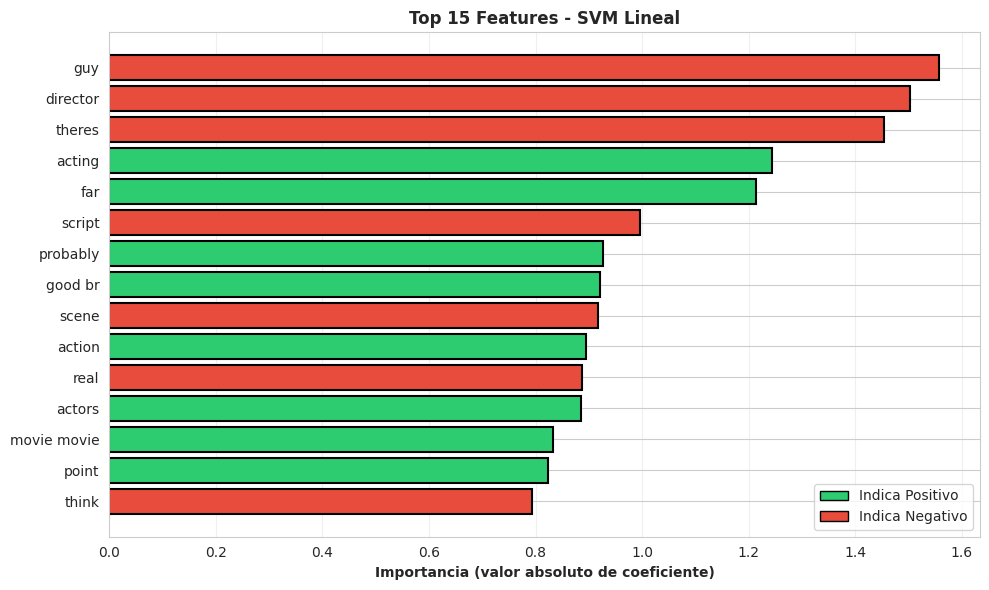

✅ Visualización guardada


In [18]:
# Visualizar feature importance
fig, ax = plt.subplots(figsize=(10, 6))

top_k = 15
top_features_idx_large = np.argsort(feature_importance_svm)[::-1][:top_k]
words = feature_names[top_features_idx_large]
importances = feature_importance_svm[top_features_idx_large]
colors_importance = ['#2ecc71' if model_svm.coef_[0][idx] > 0 else '#e74c3c' 
                     for idx in top_features_idx_large]

ax.barh(range(len(words)), importances, color=colors_importance, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.set_xlabel('Importancia (valor absoluto de coeficiente)', fontweight='bold')
ax.set_title('Top 15 Features - SVM Lineal', fontweight='bold', fontsize=12)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Añadir leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='Indica Positivo'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Indica Negativo')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'feature_importance_svm.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Visualización guardada")

## Parte 9: Predicciones en Nuevos Textos

In [19]:
print("=" * 70)
print("🔮 PREDICCIONES EN NUEVOS TEXTOS (IMDB REAL)")
print("=" * 70)

# Usar el mejor modelo (SVM)
best_model = model_svm
best_model_name = "SVM"

# Tomar algunas reviews reales del dataset IMDB test
new_review_indices = [10, 20, 30, 40]
new_reviews_raw = [decode_review(X_test_full[i], reverse_word_index) for i in new_review_indices]
new_reviews_processed = [preprocess_review(review) for review in new_reviews_raw]

print(f"\n🎬 Prediciendo sentimientos con {best_model_name} en reviews IMDB reales:")
print("\n" + "-" * 70)

for i, (raw_review, processed_review) in enumerate(zip(new_reviews_raw, new_reviews_processed), 1):
    # Vectorizar
    review_tfidf = vectorizer.transform([processed_review])
    
    # Predecir
    prediction = best_model.predict(review_tfidf)[0]
    
    # Obtener distancia desde el hiperplano (para SVM)
    distance = best_model.decision_function(review_tfidf)[0]
    confidence = np.abs(distance) / (1 + np.abs(distance))  # Normalizar a [0, 1]
    
    sentiment = "Positivo ✅" if prediction == 1 else "Negativo ❌"
    
    # Mostrar fragmento de la review original
    display_review = raw_review if len(raw_review) <= 100 else raw_review[:100] + "..."
    
    print(f"\n{i}. '{display_review}'")
    print(f"   Predicción: {sentiment}")
    print(f"   Confianza: {confidence:.2%}")

🔮 PREDICCIONES EN NUEVOS TEXTOS (IMDB REAL)

🎬 Prediciendo sentimientos con SVM en reviews IMDB reales:

----------------------------------------------------------------------

1. 'thats who dangerously checked are is manner positive br seen budget confusing this women's but often...'
   Predicción: Negativo ❌
   Confianza: 7.68%

2. 'as you with by for was one everyone's in can but good my was with appearance in same that there will...'
   Predicción: Positivo ✅
   Confianza: 20.81%

3. 'technical commander off is compelled together development as you was why as most all hideous motorcy...'
   Predicción: Negativo ❌
   Confianza: 12.95%

4. 'this is got say including this is four sly chevy country known or taylor this actually french light ...'
   Predicción: Positivo ✅
   Confianza: 32.22%


## Resumen y Conclusiones

### ✅ Lo que aprendimos:

1. **Preparar datos**: Split train/test, vectorización TF-IDF

2. **Entrenar 3 modelos clásicos**:
   - Naive Bayes: Probabilístico, muy rápido
   - SVM: Excelente con features TF-IDF
   - Logistic Regression: Rápido e interpretable

3. **Métricas de evaluación**:
   - Accuracy: % total correcto
   - Precision: Confiabilidad de predicciones positivas
   - Recall: Cobertura de casos positivos
   - F1-Score: Balance entre precision y recall

4. **Matrices de confusión**: Visualizar errores (TP, TN, FP, FN)

5. **Feature importance**: Palabras que determinan la predicción

6. **Seleccionar mejor modelo**: Basado en métricas y caso de uso

### 🎯 Cuándo usar cada modelo:

- **Naive Bayes**: Datasets pequeños, necesita velocidad, datos escasos
- **SVM**: Balance entre velocidad y precisión, features TF-IDF
- **Logistic Regression**: Producción, necesita probabilidades, interpretabilidad

### 🎓 Próximos pasos:

- Notebook 5: Deep Learning (LSTM) para mejor accuracy
- Optimizar hiperparámetros
- Cross-validation
- Manejo de clase desbalanceada

In [26]:
# 🎮 Ejercicio Interactivo: Probar con tus propias reviews del IMDB
print("=" * 70)
print("🎮 EJERCICIO INTERACTIVO")
print("=" * 70)

# Tomar una review aleatoria del IMDB test
import random
random_idx = random.randint(0, len(X_test_full) - 1)
random_review_raw = decode_review(X_test_full[random_idx], reverse_word_index)
random_review_processed = preprocess_review(random_review_raw)
random_label = y_test_full[random_idx]

# Mostrar la review
display_review = random_review_raw if len(random_review_raw) <= 200 else random_review_raw[:200] + "..."
actual_sentiment = "Positivo ✅" if random_label == 1 else "Negativo ❌"

print(f"\n📝 Review aleatoria del IMDB:")
print(f"   {display_review}")
print(f"\n📊 Sentimiento real: {actual_sentiment}\n")

# Vectorizar
review_tfidf = vectorizer.transform([random_review_processed])

# Predicciones de todos los modelos
print("Predicciones de los 3 modelos:")
print("-" * 50)

models = {'Naive Bayes': model_nb, 'SVM': model_svm, 'Logistic Regression': model_lr}
for model_name, model in models.items():
    pred = model.predict(review_tfidf)[0]
    sentiment = "Positivo ✅" if pred == 1 else "Negativo ❌"
    match = "✓ CORRECTO" if pred == random_label else "✗ ERROR"
    print(f"{model_name:<20} → {sentiment:<15} {match}")

print(f"\n💡 Tip: Ejecuta de nuevo para probar con una review diferente!")

🎮 EJERCICIO INTERACTIVO

📝 Review aleatoria del IMDB:
   was with talented is quite or as on to was well why was fantastic will due how br an as on movie is young suspects br arriving minutes episode of use version details of great maximum he had done to ma...

📊 Sentimiento real: Positivo ✅

Predicciones de los 3 modelos:
--------------------------------------------------
Naive Bayes          → Positivo ✅      ✓ CORRECTO
SVM                  → Positivo ✅      ✓ CORRECTO
Logistic Regression  → Positivo ✅      ✓ CORRECTO

💡 Tip: Ejecuta de nuevo para probar con una review diferente!
